# Galaxy clusters in Euclid Q1

**AAS workshop:** *Euclid Data in the Cloud - Access, Analysis, and Science Opportunities* (90 min)

_Notebook 3 of 4._ This notebook reuses the **same TAP / SIA / direct-S3 patterns** from [`2_Euclid_data_cloud.ipynb`](2_Euclid_data_cloud.ipynb), now applied to a real science problem: looking at a Q1 galaxy cluster and pulling out its candidate member galaxies.

Q1 ships with a catalog of ~35 detected galaxy clusters across the three deep fields ([Euclid Collaboration: Bhargava et al. 2025, arXiv:2503.19196](https://arxiv.org/abs/2503.19196)). That paper builds a complete cluster-finding pipeline; we'll do the lightweight version that just asks:

1. Where is a chosen Q1 cluster on the sky?
2. What galaxies sit near it at the right photo-z?
3. What does the cluster region look like in Euclid NIR imaging?
4. Does the photo-z distribution show the expected over-density at the cluster's redshift?

**What's new compared to notebook 2:**
- **Region queries** instead of single-source lookups — `CIRCLE(...)` in ADQL.
- **JOIN across catalogs** — MER (positions, fluxes) ⨝ PHZ (photo-z) by `object_id`.
- **Population visualization** — overlaying many sources on an image, not just one.

Adapted (heavily simplified) from the [IRSA Euclid Q1 clusters tutorial](https://caltech-ipac.github.io/irsa-tutorials/euclid-clusters-tutorial/). The full IRSA tutorial adds DBSCAN clustering, color-magnitude diagrams, stacked spectra, and NED cross-matching — useful for serious science, deferred here for time.

## 0. Setup

Same imports as notebook 2. The cluster catalog (35 rows, positions + redshifts + richness) is shipped with the repo at `AAS247/euclid_q1_clusters.csv` and loaded with `astropy.table.Table`.

In [ ]:
# Uncomment the following line to install the dependencies.
# !pip install -r requirements.txt

In [27]:
import json

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.table import Table
from astropy.visualization import AsinhStretch, ImageNormalize, PercentileInterval
from astropy.wcs import WCS
from astroquery.ipac.irsa import Irsa

from workshop_utils import tap_query_with_retry, irsa_with_retry

clusters = Table.read('AAS247/euclid_q1_clusters.csv', format='ascii.csv')
print(f'Loaded {len(clusters)} Q1 clusters.')
print(f'Columns: {clusters.colnames}')

Loaded 35 Q1 clusters.
Columns: ['NAME', 'ID', 'RAPZWav', 'DecPZWav', 'RAAMICO', 'DecAMICO', 'zPZWav', 'zAMICO', 'zspec', 'Nzspec', 'SNRPZWav', 'SNRAMICO', 'lambdaPmem']


## 1. Pick a target cluster

The Q1 cluster catalog gives two estimators per cluster — `PZWav` (a photometric wavelet-based detection) and `AMICO` (matched-filter). Both produce a position and a redshift; we'll use the AMICO redshift since it's the more standard cluster-finder. `lambdaPmem` is the **richness**: roughly the count of probable member galaxies inside a fiducial radius, weighted by membership probability — a proxy for cluster mass.

We'll pick a cluster that's (a) high richness, so the over-density is visually obvious, and (b) has an external spec-z so we trust the redshift. The cell below sorts by richness, marks clusters with spec-z, and lets you choose.

In [32]:
# Richness is stored as a string like "241.47±4.79"; parse the value out for sorting.
richness = np.array([float(str(s).split('±')[0]) for s in clusters['lambdaPmem']])
order = np.argsort(-richness)  # descending
top = clusters[order][:10]
top[['NAME', 'RAAMICO', 'DecAMICO', 'zAMICO', 'zspec', 'lambdaPmem']].pprint(max_lines=-1, max_width=140)

# Pick EUCL-Q1-CL-2: high richness, has external spec-z (z = 0.535 +/- 0.004 from 10 redshifts),
# and sits in the EDF-Fornax field where Q1 imaging is deep. Change CLUSTER_NAME to demo a
# different cluster — the rest of the notebook follows whichever one you pick.
CLUSTER_NAME = 'EUCL-Q1-CL J033412.98−282418.7'
row = clusters[clusters['NAME'] == CLUSTER_NAME][0]

CLUSTER_RA = float(row['RAAMICO'])
CLUSTER_DEC = float(row['DecAMICO'])
CLUSTER_Z = float(row['zAMICO'])
CLUSTER_CENTER = SkyCoord(ra=CLUSTER_RA * u.deg, dec=CLUSTER_DEC * u.deg)
print(f'\nTarget: {CLUSTER_NAME}')
print(f'  Center: RA, Dec = {CLUSTER_RA:.4f}, {CLUSTER_DEC:.4f}')
print(f'  Cluster z = {CLUSTER_Z:.3f}  (external spec-z: {row["zspec"]})')
print(f'  Richness  = {row["lambdaPmem"]}')

             NAME              RAAMICO DecAMICO zAMICO    zspec     lambdaPmem
------------------------------ ------- -------- ------ ----------- -----------
EUCL-Q1-CL J041113.88−481928.2 62.8067 -48.3245    0.4           - 241.47±4.79
EUCL-Q1-CL J040558.72−491549.3 61.4875 -49.2648    0.3           - 131.57±4.40
EUCL-Q1-CL J041724.90−474849.7 64.3554 -47.8127   0.56           - 115.26±4.13
EUCL-Q1-CL J040509.84−464902.4 61.2865  -46.825   0.38           -  99.49±4.55
EUCL-Q1-CL J040655.77−480504.2 61.7365  -48.084    0.7           -  99.21±3.72
EUCL-Q1-CL J040151.05−502848.7 60.4568 -50.4824   0.42           -  99.03±4.45
EUCL-Q1-CL J040406.81−481302.2 61.0324 -48.2148    0.4           -  98.53±5.27
EUCL-Q1-CL J033412.98−282418.7  53.557 -28.4039   0.66 0.662±0.007  97.08±2.75
EUCL-Q1-CL J033747.63−275112.8 54.4478 -27.8574   0.48 0.535±0.004  81.36±4.74
EUCL-Q1-CL J041838.86−455252.9 64.6593 -45.8821   0.62           -  76.28±4.23

Target: EUCL-Q1-CL J033412.98−282418.7
  Center: RA

## 2. Candidate cluster members — TAP with `CIRCLE` and `JOIN`

To find galaxies that *might* be cluster members we need two things per source:

- **Position** — to keep only sources near the cluster center.
- **Photo-z** — to keep only sources in a narrow slice around the cluster redshift.

Positions live in **`euclid_q1_mer_catalogue`**; photo-z lives in **`euclid_q1_phz_photo_z`**. Both tables share an `object_id` column, so we can fetch the joined information in one ADQL query using a `JOIN`. The spatial constraint is an ADQL `CIRCLE` — the IVOA syntax for a cone search written inline in SQL.

We run the **identical query twice**: once at the cluster center, once at a **control center 5′ south** of it. The control sits clearly outside the cluster's R₂₀₀ (~5–6′ for richness λ ≈ 81) but on the same MER tile, so depth and selection are comparable. If the cluster signal is real, the cluster pointing should show a spatial over-density that the control does not.

Cuts we apply:

- **`CIRCLE(..., 0.05 deg) = 1`** — 3 arcmin radius, ~1.3 Mpc at z = 0.5.
- **`phz_classification = 2`** — galaxies only (1 = star, 2 = galaxy, 3 = QSO in PHZ's encoding).
- **`ABS(phz_median - z_cluster) < 0.05`** — narrow photo-z slice around the cluster (~1× the photo-z uncertainty).

In [33]:
RADIUS_DEG = 0.05            # 3 arcmin
DZ = 0.05                    # narrow photo-z slice (~1x photo-z uncertainty)
CONTROL_OFFSET_ARCMIN = 5.0  # control center this far SOUTH of the cluster

CONTROL_CENTER = SkyCoord(ra=CLUSTER_RA * u.deg,
                          dec=(CLUSTER_DEC - CONTROL_OFFSET_ARCMIN / 60) * u.deg)
print(f'Control center: RA, Dec = {CONTROL_CENTER.ra.deg:.4f}, {CONTROL_CENTER.dec.deg:.4f}')

def members_query(ra_c, dec_c):
    return f"""
SELECT m.object_id, m.ra, m.dec, m.flux_h_templfit, m.flux_vis_psf,
       p.phz_median, p.phz_classification
FROM   euclid_q1_mer_catalogue AS m
JOIN   euclid_q1_phz_photo_z   AS p  ON m.object_id = p.object_id
WHERE  CONTAINS(POINT('ICRS', m.ra, m.dec),
                CIRCLE('ICRS', {ra_c}, {dec_c}, {RADIUS_DEG})) = 1
  AND  p.phz_classification = 2
  AND  ABS(p.phz_median - {CLUSTER_Z}) < {DZ}
  AND  m.flux_h_templfit > 0
"""

# Underlying call: Irsa.query_tap(adql).to_table(); the wrapper retries on transient 5xx.
members = tap_query_with_retry(members_query(CLUSTER_RA, CLUSTER_DEC))
control = tap_query_with_retry(members_query(CONTROL_CENTER.ra.deg, CONTROL_CENTER.dec.deg))
print(f'Cluster field: {len(members):4d} candidate members within {RADIUS_DEG*60:.1f}\'.')
print(f'Control field: {len(control):4d} candidate sources within {RADIUS_DEG*60:.1f}\'.')

Control center: RA, Dec = 53.5570, -28.4872
Cluster field:  248 candidate members within 3.0'.
Control field:  181 candidate sources within 3.0'.


## 3. NIR image cutouts — SIA + direct S3

Now grab H-band cutouts for **both** the cluster and the control center. Same SIA → S3 → `Cutout2D` pattern as notebook 2 §2, just bigger (~3 arcmin square instead of 20 arcsec) and twice — we open the mosaic FITS once and slice two `Cutout2D` regions out of it.

The H band traces evolved stellar populations: a cluster at z ~ 0.5 should show up as a concentration of red galaxies in one panel; the control panel should look like a regular galaxy field.

In [34]:
# Underlying call: Irsa.query_sia(...); the wrapper retries on transient 5xx.
sia = irsa_with_retry(Irsa.query_sia, pos=(CLUSTER_CENTER, 1 * u.arcsec),
                      collection='euclid_DpdMerBksMosaic')
h_row = sia[sia['energy_bandpassname'] == 'H'][0]
aws = json.loads(h_row['cloud_access'])['aws']
s3_uri = f"s3://{aws['bucket_name']}/{aws['key']}"
print(f'H-band mosaic S3 URI:\n  {s3_uri}')

# Open the mosaic once and slice two 3-arcmin cutouts — cluster and control —
# from the same FITS. The control 5\' south of the cluster sits comfortably on
# the same MER tile.
CUTOUT_SIZE = 3 * u.arcmin
with fits.open(s3_uri, fsspec_kwargs={'anon': True}) as hdul:
    wcs = WCS(hdul[0].header)
    cutout = Cutout2D(hdul[0].section, position=CLUSTER_CENTER,
                      size=CUTOUT_SIZE, wcs=wcs)
    cutout_ctrl = Cutout2D(hdul[0].section, position=CONTROL_CENTER,
                           size=CUTOUT_SIZE, wcs=wcs)
print(f'Cluster cutout: {cutout.data.shape} pix    '
      f'Control cutout: {cutout_ctrl.data.shape} pix')

H-band mosaic S3 URI:
  s3://nasa-irsa-euclid-q1/q1/MER/102043550/NISP/EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102043550-157BA3_20241021T001915.125515Z_00.00.fits
Cluster cutout: (1800, 1800) pix    Control cutout: (1800, 1800) pix


## 4. DBSCAN side-by-side — cluster vs control

The DBSCAN result above only means something if the *same* algorithm with the *same* parameters finds **nothing** when pointed at a random patch of sky. We run [DBSCAN](https://scikit-learn.org/stable/modules/clustering.html#dbscan) — an unsupervised clustering algorithm that finds dense regions in spatial data — on both fields with identical settings.

We project candidate positions to angular offsets in arcseconds from each field center, then run DBSCAN with:

- **`eps = 20″`** — a galaxy is a neighbor if it sits within 20″ (~130 kpc at z = 0.48, cluster-core scale).
- **`min_samples`** — set *adaptively* from the cluster field to require **≥ 1.5× the field background density**, then **applied unchanged to the control field**. That's the key test: identical threshold, different sky.

**Symbol legend.** In each panel, **red** circles are sources DBSCAN flagged as part of the densest over-density (candidate cluster members). **Gray** circles are the other sources that passed the photo-z and position cuts but were not flagged — the *non-cluster* galaxy population at this redshift. If the cluster signal is real, the left panel should show a clear concentration of red circles near bright galaxies in the cluster core, and the right panel should show very few or none.

cluster-field density ≈ 8.77 sources/arcmin²; using eps=20", min_samples=5 (>=1.5x background contrast).
DBSCAN cluster field:  73 over-density members out of 248 candidates
DBSCAN control field:  25 over-density members out of 181 candidates


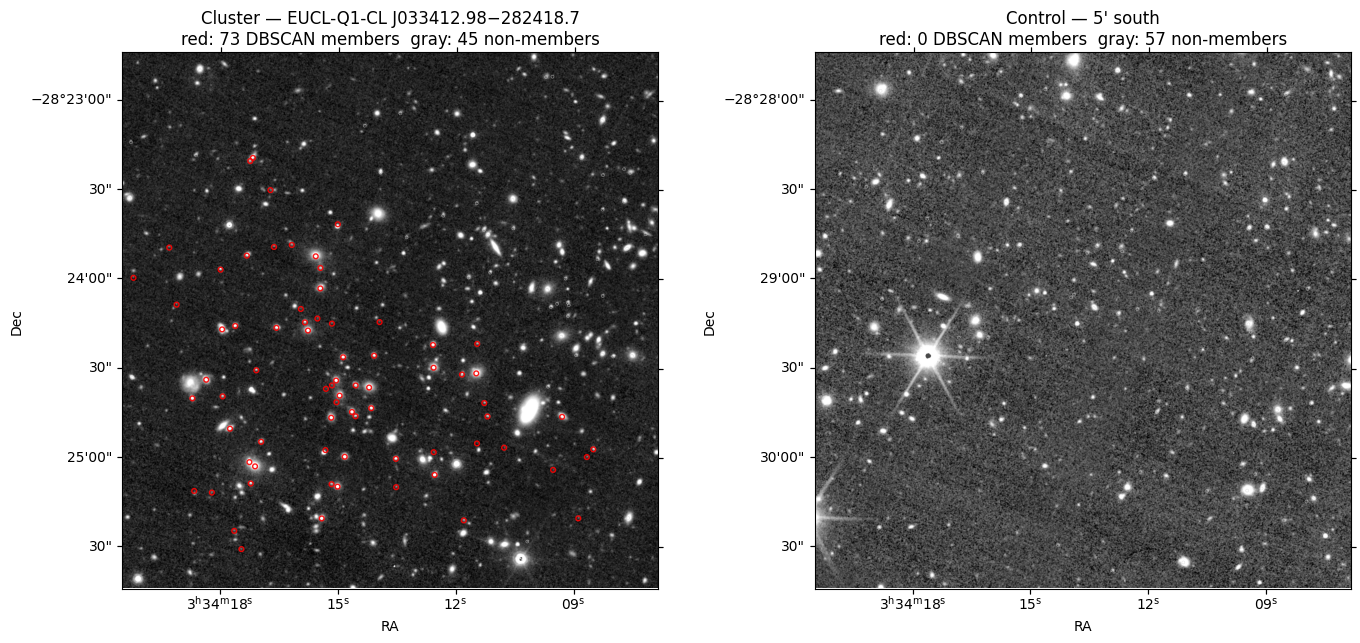

In [35]:
from sklearn.cluster import DBSCAN

def project_to_arcsec(tab, ra_c, dec_c):
    """Local tangent-plane offsets in arcsec from (ra_c, dec_c)."""
    dra = (np.asarray(tab['ra']) - ra_c) * np.cos(np.radians(dec_c)) * 3600
    ddec = (np.asarray(tab['dec']) - dec_c) * 3600
    return np.column_stack([dra, ddec])

# Calibrate min_samples on the cluster field, then reuse the same integer on
# the control field so the threshold is identical in both runs.
EPS_ARCSEC = 20.0
CONTRAST = 1.5
field_density = len(members) / (np.pi * (RADIUS_DEG * 3600) ** 2)
MIN_SAMPLES = max(5, int(CONTRAST * field_density * np.pi * EPS_ARCSEC ** 2))
print(f'cluster-field density ≈ {field_density*3600:.2f} sources/arcmin²; '
      f'using eps={EPS_ARCSEC:.0f}\", min_samples={MIN_SAMPLES} '
      f'(>={CONTRAST}x background contrast).')

def run_dbscan(tab, ra_c, dec_c):
    xy = project_to_arcsec(tab, ra_c, dec_c)
    labels = DBSCAN(eps=EPS_ARCSEC, min_samples=MIN_SAMPLES).fit(xy).labels_
    ids, counts = np.unique(labels[labels >= 0], return_counts=True)
    if len(ids):
        return labels == ids[np.argmax(counts)]
    return np.zeros(len(tab), dtype=bool)

is_cluster = run_dbscan(members, CLUSTER_RA, CLUSTER_DEC)
is_ctrl    = run_dbscan(control, CONTROL_CENTER.ra.deg, CONTROL_CENTER.dec.deg)
print(f'DBSCAN cluster field: {is_cluster.sum():3d} over-density members '
      f'out of {len(members)} candidates')
print(f'DBSCAN control field: {is_ctrl.sum():3d} over-density members '
      f'out of {len(control)} candidates')

# Side-by-side image panels with member overlays.
def plot_panel(ax, cutout_obj, tab, is_member, title):
    norm = ImageNormalize(cutout_obj.data, interval=PercentileInterval(99),
                          stretch=AsinhStretch())
    ax.imshow(cutout_obj.data, origin='lower', cmap='gray', norm=norm)
    xy_pix = cutout_obj.wcs.world_to_pixel(SkyCoord(ra=tab['ra'], dec=tab['dec']))
    ny, nx = cutout_obj.data.shape
    in_frame = (xy_pix[0] >= 0) & (xy_pix[0] < nx) & (xy_pix[1] >= 0) & (xy_pix[1] < ny)
    for x, y in zip(xy_pix[0][in_frame & ~is_member], xy_pix[1][in_frame & ~is_member]):
        ax.add_patch(Circle((x, y), radius=5, edgecolor='lightgray',
                            facecolor='none', lw=0.4, alpha=0.6))
    for x, y in zip(xy_pix[0][in_frame & is_member], xy_pix[1][in_frame & is_member]):
        ax.add_patch(Circle((x, y), radius=8, edgecolor='red',
                            facecolor='none', lw=1.0, alpha=0.9))
    ax.set_title(f'{title}\nred: {(in_frame & is_member).sum()} DBSCAN members  '
                 f'gray: {(in_frame & ~is_member).sum()} non-members')
    ax.set_xlabel('RA'); ax.set_ylabel('Dec')

fig = plt.figure(figsize=(14, 6.5))
ax1 = fig.add_subplot(1, 2, 1, projection=cutout.wcs)
plot_panel(ax1, cutout, members, is_cluster, f'Cluster — {CLUSTER_NAME}')
ax2 = fig.add_subplot(1, 2, 2, projection=cutout_ctrl.wcs)
plot_panel(ax2, cutout_ctrl, control, is_ctrl,
           f'Control — {CONTROL_OFFSET_ARCMIN:.0f}\' south')
plt.tight_layout(); plt.show()

## Wrap-up

Same access toolkit as notebook 2 — TAP, SIA, direct S3 — applied to a population-level science question:

- **TAP `JOIN`** combined positions (MER) with photo-z (PHZ) in one query.
- **ADQL `CIRCLE`** did the spatial cut inline, no client-side filtering.
- **SIA + direct S3 + `Cutout2D`** pulled the imaging without downloading the 1.4 GB mosaic.

From here it's a short walk to the IRSA tutorial's fuller pipeline — DBSCAN to refine the spatial selection, color-magnitude diagrams to isolate the red sequence, stacked SIR spectra to confirm cluster-frame emission lines, NED cross-match to identify spectroscopic members. All of those use exactly the same access patterns; only the analysis on top changes.